# Project Goal

* **To expand/improve on the Initial analysis**
  
* **Include New Prediction Models**

* **Optimise the models created for better results**

* **Evaluate the Results**



### Major target Challenges
* Identify Critical Features  
* Class Balancing 
* Modelling
* Hyper Parameter Tuning
* Threshold Optimization
* Final Evaluation and Recommendation

*Key Assumptions: A "Missed Failure" is significantly more costly than a "False Alarm".*

## Import Required Library & Dataset

In [1]:
# Download Requirements where neccessary
import sys
!{sys.executable} -m pip install -r ../requirements.txt


In [42]:
import os
from pathlib import Path
import pandas as pd
import numpy as np  # NumPy 1.26.4.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.combine import SMOTEENN
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import ConfusionMatrixDisplay, make_scorer, roc_curve
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, recall_score, precision_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns


We will import the already preprocessed UCI_SECOM Dataset and seperate our features into  
Target 'y' and  Predictor 'x' variables

In [48]:
project_root = Path('..') 

raw_data_path = project_root/'data'/'raw'
processed_data_path = project_root/'data'/'processed'

df = pd.read_csv(processed_data_path/'cleaned_data.csv')
df.head(100)

,0,1,2,3,4,6,12,14,15,16,...,563,564,569,570,571,572,573,585,589,Pass/Fail
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,97.6133,202.4396,7.9558,414.8710,10.0433,...,0.679641,6.444985,21.117674,533.8500,2.1113,8.95,0.3157,2.3630,99.670066,0
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,102.3433,200.5470,10.1548,414.7347,9.2599,...,0.679641,6.444985,21.117674,535.0164,2.4335,5.92,0.2653,4.4447,208.204500,0
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,95.4878,202.0179,9.5157,416.7075,9.3144,...,0.903200,1.100000,68.848900,535.0245,2.0293,11.21,0.1882,3.1745,82.860200,1
3,2988.72,2479.90,2199.0333,909.7926,1.3204,104.2367,201.8482,9.6052,422.2894,9.6924,...,0.651100,7.320000,25.036300,530.5682,2.0253,9.33,0.1738,2.0544,73.843200,0
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.3967,201.9424,10.5661,420.5925,10.3387,...,0.679641,6.444985,21.117674,532.0155,2.0275,8.83,0.2224,99.3032,73.843200,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,3081.07,2560.99,2180.1556,1822.5073,1.2579,98.1289,203.2749,13.4292,408.6389,10.0165,...,0.678200,7.390000,16.774500,534.9591,1.8002,8.29,0.2435,1.9607,114.749700,0
96,2992.40,2467.07,2191.6667,1107.4330,1.3529,103.4233,199.6784,7.6212,395.5722,10.1679,...,0.755500,10.290000,6.467100,533.9136,2.4527,9.27,0.4407,6.5274,192.298500,1
97,3049.31,2453.82,2265.1889,1740.3297,1.4715,100.3889,198.6113,15.4785,422.5091,10.3122,...,0.679641,6.444985,21.117674,531.6718,2.3956,10.26,0.3566,3.4900,192.298500,0
98,3011.49,2537.90,2183.4556,955.9073,1.1048,102.6978,198.9000,14.0894,416.6665,10.3165,...,0.679641,6.444985,21.117674,529.0600,2.3468,8.19,0.2909,2.2104,192.298500,0


## Exploratory Data Analysis & Pre-Processing

In [49]:
# Seperating Target 'x' and Predictor Variables
x = df.drop(columns=['Pass/Fail']) 
y = df['Pass/Fail']

In [50]:
# Force the entire Predictor feature set to numeric
x = x.apply(pd.to_numeric, errors='coerce')

In [51]:
x.isna().sum() # Confirms that there are no Null values

0      0
1      0
2      0
3      0
4      0
      ..
571    0
572    0
573    0
585    0
589    0
Length: 195, dtype: int64

In [54]:
y.head().to_list()

[0, 0, 1, 0, 0]

In [55]:
display(df.describe())
df.shape

,0,1,2,3,4,6,12,14,15,16,...,563,564,569,570,571,572,573,585,589,Pass/Fail
count,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,...,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000
mean,3014.452896,2495.850231,2200.547318,1396.376627,4.197013,101.112908,199.956809,9.005371,413.086035,9.907603,...,0.679641,6.444985,21.117674,530.523623,2.101836,28.450165,0.345636,3.067826,99.670066,0.066369
std,73.480613,80.227793,29.380932,439.712852,56.103066,6.209271,3.255195,2.793916,17.204591,2.401563,...,0.110637,2.393043,9.280454,17.499736,0.275112,86.304681,0.248478,3.576891,93.861936,0.249005
min,2743.240000,2158.750000,2060.660000,0.000000,0.681500,82.131100,182.094000,2.249300,333.448600,4.469600,...,0.304900,0.970000,3.250400,317.196400,0.980200,3.540000,0.066700,1.197500,0.000000,0.000000
25%,2966.665000,2452.885000,2181.099950,1083.885800,1.017700,97.937800,198.130950,7.096750,406.131000,9.568550,...,0.567100,4.980000,15.466200,530.702700,1.982900,7.500000,0.242250,2.306500,44.368600,0.000000
50%,3011.840000,2498.910000,2200.955600,1287.353800,1.317100,101.492200,199.537100,8.973900,412.262900,9.852000,...,0.679641,6.290000,20.182400,532.398200,2.118600,8.650000,0.293400,2.757700,72.023000,0.000000
75%,3056.540000,2538.745000,2218.055500,1590.169900,1.529600,104.530000,202.006750,10.858700,419.082800,10.127750,...,0.738250,7.310000,23.035200,534.356400,2.290650,10.130000,0.366900,3.294950,114.749700,0.000000
max,3356.350000,2846.440000,2315.266700,3715.041700,1114.536600,129.252200,272.045100,19.546500,824.927100,102.867700,...,1.298800,32.580000,84.802400,589.508200,2.739500,454.560000,2.196700,99.303200,737.304800,1.000000


(1567, 196)

Looking closely at the dataset you'll observe that we still have a high number of Features(196) which is still too much for a model to learn from without absorbing noise.  
Therefore its important we carryout further feature selection to further reduce the number of features. But firstly, I will run correlation analysis to gain insight on features behaviour. 

*Recall: we initially used multicolinearity to reduce the number of features in the **'Initial Analysis'** notebook.*


We shall now use Target Correlation to understand which sensors actually have a direct relationship with the Pass/Fail result?  
Target Correlation tells us which features "move" the target from 0 to 1. 

* Positive Correlation: means that as the sensor value increases, the likelihood of a "Fail" (1) also increases.  
* Negative Correlation: means that as the sensor value increases, the likelihood of a "Fail" (1) decreases.  
* Zero Correlation: means that changes in the sensor have no predictable impact on whether the product passes or fails. These sensors are noise and should be removed. 

In [13]:
corr = x.copy()
corr['target'] = y

corr_values = corr.corr()['target'].drop('target').sort_values()

print(corr_values.abs().sort_values(ascending=False).tail(5))
print(corr_values.abs().sort_values(ascending=False).head(5))

154    0.001564
472    0.001219
223    0.001068
2      0.000957
429    0.000275
Name: target, dtype: float64
59     0.155771
510    0.131587
431    0.120304
434    0.111609
430    0.109569
Name: target, dtype: float64



The above Correlation analysis reveals that with maximum correlation values around ±0.15, no single sensor strongly determines failure. This suggests that failure is driven by complex interactions between multiple process variables rather than individual sensor readings.



## 1). Identify the Important Features 

Ideally, If a feature has near-zero correlation with the target, it’s likely noise and can be dropped.

However, Standard correlation (Pearson) only looks for linear relationships. Since sensor data can be non-linear, a low correlation score doesn't always mean a feature is useless, it just means the relationship isn't straightforward. 

In manufacturing, a sensor might only indicate a "Fail" when it hits an extreme high or low value, or when it interacts with another sensor.  
For this reason we cannot use Correlation which only measures linear relationships to the target variable to determine feature importance, instead we will make use of the Random Forest importance model.

The Random Forest Feature importance model measures how much each sensor contributes to reducing uncertainty across all decision trees in the forest.  

This model can detect the non-linear patterns which a correlation threshold might incorrectly discard as irrelevant. It identifies features that are highly predictive when combined with others at different decision nodes.

Random Forest is designed to thrive in high-dimensional data by selecting random subspaces of features to find the most informative ones.


In [14]:
# Firstly, we split the data
rfX_train, rfX_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [15]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(rfX_train, y_train)
important = pd.Series(rf.feature_importances_, index=rfX_train.columns)

*Note:* 'balanced' weight helps the model focus on the rare 'fail' cases  


Then we can now sort and select the top 50 sensors and view thier level of importance to the model

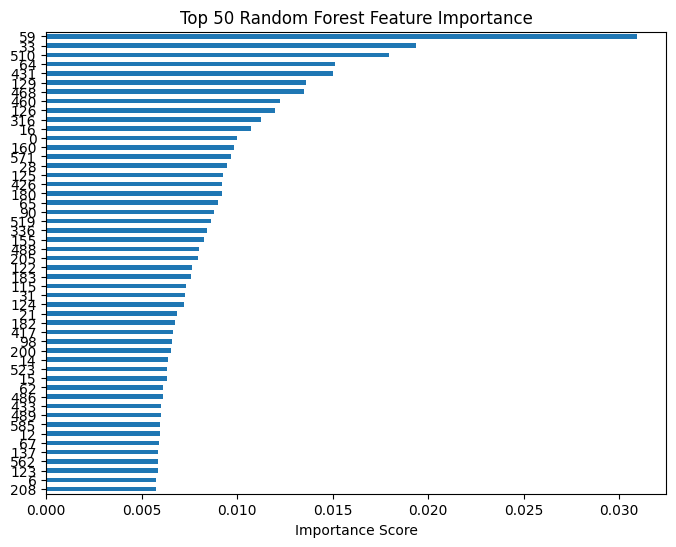

In [16]:
top_sensors = important.sort_values(ascending=False).head(50)

top_sensors.sort_values().plot(kind='barh', figsize=(8,6)) 
plt.title("Top 50 Random Forest Feature Importance") 
plt.xlabel("Importance Score") 
plt.show()

In [18]:
# Matching the Selected Features
selected_sensors = top_sensors.index.to_list()
X_train = rfX_train[selected_sensors]
X_test = rfX_test[selected_sensors]
X_test.shape

(314, 50)

From the above result, we have sucessfully reduced the total number of features to the top 50 most important features this will help reduce uncertainy in the various models we are about to create.

In [19]:
# scaling the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 2). Resampling using SMOTE

 One of the major challenges of the UCI-SECOM dataset is class imbalance.  
When one class (the majority) significantly outnumbers another (the minority), models often become biased by favoring the majority class and failing to identify the rare but important events (in this case failure cases).

We can try to solve the issue by initializing the hyperparmeter (class_weight = 'balanced') but this wont be effective in getting the desired result hence, we have to try the SMOTE method of resampling which is a more efficient means of balancing target features. 




The SECOM dataset is characterized by extreme class imbalance (roughly 14:1 ratio of pass to fail), high dimensionality (590 features), and significant noise from sensor measurements. 

While standard SMOTE blindly creates new synthetic samples to balance the dataset using nearest neighbors (Euclidean distance), SMOTENN adds a second step using Edited Nearest Neighbors (ENN) to remove noisy, ambiguous synthetic data points.


Also, since SECOM features often overlap. SMOTENN prunes borderline instances from both classes that are likely to be misclassified therby creating a cleaner and more distinct separation for the models to learn from.


*Note:  
Currently, Our dataset has roughly 14 "Pass" results for every 1 "Fail".  
If we train a model on that, it will likely achieve about 93% accuracy just by guessing "Pass" every time, which is useless for finding defective chips.*

In [20]:
y_train.value_counts()

Pass/Fail
0    1173
1      80
Name: count, dtype: int64

In [21]:
sm = SMOTEENN(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_scaled, y_train) 
print(f"Class Distribution after SMOTE: \n {y_train_resampled.value_counts()}") # Checks the new class distribution

Class Distribution after SMOTE: 
 Pass/Fail
1    1173
0     616
Name: count, dtype: int64


The reason our classes aren't perfectly balanced (ie. 1173 vs 1173) is because SMOTEENN is a hybrid technique that performs two steps:  
SMOTE (Oversampling):  That creates synthetic examples to balance the classes.  
ENN (Cleaning):  This is the "Edited Nearest Neighbors" part. It looks at the data points and deletes any that are noisy or sit too close to the boundary of the opposite class.

It deleted them to make the boundary between classes cleaner and easier for your model to learn.
 By removing the overlapping points, we are reducing the risk of our models getting "confused" by outliers, which often leads to better Precision and Recall scores.



For a balanced resampling we could use standard SMOTE instead but we are using SMOTENN for best result.


## 3). Initial Modelling

### Logistic Regression Model

In [22]:
logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logreg.fit(X_train_resampled, y_train_resampled)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [23]:
y_pred_lr = logreg.predict(X_test_scaled)
y_proba_lr = logreg.predict_proba(X_test_scaled)[:,1]

print("Logistic Regression")
print("ROC AUC:", roc_auc_score(y_test, y_proba_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression
ROC AUC: 0.6614942528735632
[[205  85]
 [ 11  13]]
              precision    recall  f1-score   support

           0       0.95      0.71      0.81       290
           1       0.13      0.54      0.21        24

    accuracy                           0.69       314
   macro avg       0.54      0.62      0.51       314
weighted avg       0.89      0.69      0.76       314



### Random Forest Classifier Model 

In [24]:
rf_model = RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled) # We do not fit tree based models to scaled data

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [25]:
y_pred_rf = rf_model.predict(X_test_scaled)
y_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Random Forest")
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf)) 
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
ROC AUC: 0.7361350574712643
[[236  54]
 [ 12  12]]
              precision    recall  f1-score   support

           0       0.95      0.81      0.88       290
           1       0.18      0.50      0.27        24

    accuracy                           0.79       314
   macro avg       0.57      0.66      0.57       314
weighted avg       0.89      0.79      0.83       314



### Support Vector Classifier Model

In [26]:
svc_model = SVC(kernel='rbf', probability=True, class_weight='balanced', max_iter=1000, random_state=42)
svc_model.fit(X_train_resampled, y_train_resampled)

C:\Users\CJ\miniconda3\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [27]:
y_pred_svc = svc_model.predict(X_test_scaled)
y_proba_svc = svc_model.predict_proba(X_test_scaled)[:, 1]

print("SVC Performance")
print("ROC AUC:", roc_auc_score(y_test, y_proba_svc))
print(confusion_matrix(y_test, y_pred_svc))
print(classification_report(y_test, y_pred_svc))

SVC Performance
ROC AUC: 0.6817528735632183
[[245  45]
 [ 15   9]]
              precision    recall  f1-score   support

           0       0.94      0.84      0.89       290
           1       0.17      0.38      0.23        24

    accuracy                           0.81       314
   macro avg       0.55      0.61      0.56       314
weighted avg       0.88      0.81      0.84       314



### Build and Train the XGBoost Model

Unlike standard Random Forest, XGBoost has built-in L1 and L2 regularization, which helps it handle the noisy nature of semiconductor sensor data.

In [28]:
# use_label_encoder=False avoids a common deprecation warning
# eval_metric='logloss' is the standard for binary classification
xgb_model = XGBClassifier( n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, 
                          use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_resampled, y_train_resampled)

C:\Users\CJ\miniconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [04:02:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [29]:
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("XGBoost Performance :")
print("ROC AUC:", roc_auc_score(y_test, y_proba_xgb))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Performance :
ROC AUC: 0.7584770114942528
Confusion Matrix:
[[233  57]
 [ 11  13]]
              precision    recall  f1-score   support

           0       0.95      0.80      0.87       290
           1       0.19      0.54      0.28        24

    accuracy                           0.78       314
   macro avg       0.57      0.67      0.57       314
weighted avg       0.90      0.78      0.83       314



### Build and Train the LGBMClassifier

In [30]:
# 'is_unbalance=True' is great for your imbalanced classes!
lgbm_model = LGBMClassifier(n_estimators=100, learning_rate=0.1, num_leaves=31, 
                            is_unbalance=True )
lgbm_model.fit(X_train_resampled, y_train_resampled)

[LightGBM] [Info] Number of positive: 1173, number of negative: 616
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000782 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12747
[LightGBM] [Info] Number of data points in the train set: 1789, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.655674 -> initscore=0.644073
[LightGBM] [Info] Start training from score 0.644073


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [31]:
y_pred_lgbm = lgbm_model.predict(X_test_scaled)
y_proba_lgbm = lgbm_model.predict_proba(X_test_scaled)[:, 1]

print("LGBMClassifier")
print("ROC AUC:", roc_auc_score(y_test, y_proba_lgbm))
print(confusion_matrix(y_test, y_pred_lgbm))
print(classification_report(y_test, y_pred_lgbm))

LGBMClassifier
ROC AUC: 0.7439655172413794
[[239  51]
 [ 13  11]]
              precision    recall  f1-score   support

           0       0.95      0.82      0.88       290
           1       0.18      0.46      0.26        24

    accuracy                           0.80       314
   macro avg       0.56      0.64      0.57       314
weighted avg       0.89      0.80      0.83       314



C:\Users\CJ\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\CJ\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Examining the Initial Results

In [32]:
all_models = {
    'Logistic Regression': logreg,
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
     'SVM': svc_model,
     'LightGBM': lgbm_model
}
initial_results = []
for name, model in all_models.items():
    print(f"\n--- {name} Performance ---")
    y_pred = model.predict(X_test_scaled) # Use your original X_test here
    print(classification_report(y_test, y_pred))

    initial_results.append({
        'Model': name,
        'Recall (Fail)': round(recall_score(y_test, y_pred), 3),
        'Precision (Fail)': round(precision_score(y_test, y_pred), 3),
        'F1-Score': round(f1_score(y_test, y_pred), 3)
        })
    tune_comparison_df = pd.DataFrame(initial_results) 
print('\n', 'Initial Metrics Report', '\n', tune_comparison_df.sort_values(by='Recall (Fail)', ascending=False))



--- Logistic Regression Performance ---
              precision    recall  f1-score   support

           0       0.95      0.71      0.81       290
           1       0.13      0.54      0.21        24

    accuracy                           0.69       314
   macro avg       0.54      0.62      0.51       314
weighted avg       0.89      0.69      0.76       314


--- Random Forest Performance ---
              precision    recall  f1-score   support

           0       0.95      0.81      0.88       290
           1       0.18      0.50      0.27        24

    accuracy                           0.79       314
   macro avg       0.57      0.66      0.57       314
weighted avg       0.89      0.79      0.83       314


--- XGBoost Performance ---
              precision    recall  f1-score   support

           0       0.95      0.80      0.87       290
           1       0.19      0.54      0.28        24

    accuracy                           0.78       314
   macro avg       0.57

C:\Users\CJ\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


C:\Users\CJ\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


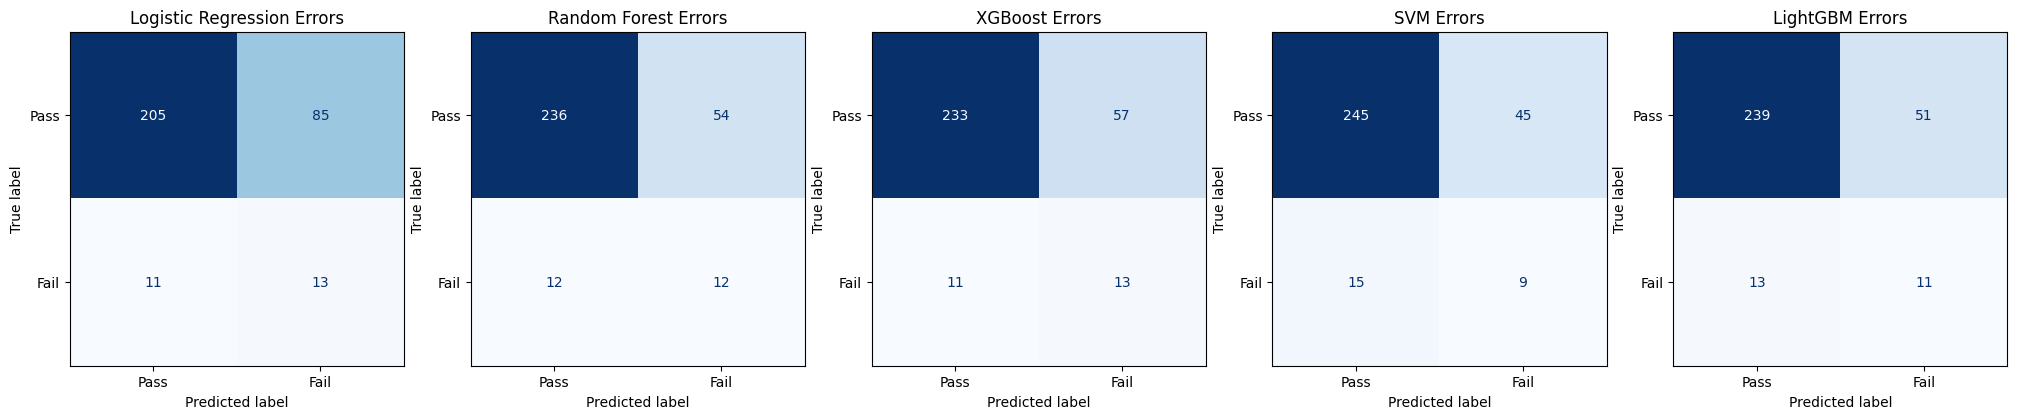

In [33]:
# To examine their confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, (name, model) in enumerate(all_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pass', 'Fail'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'{name} Errors')

plt.show()


The above confusion matrix displays exactly where the models are making mistakes.

All five models exhibit a high false-negative rate, failing to detect nearly 50% of defective chips due to the severe class imbalance favoring "Pass" predictions. 

XGBoost and Logistic Regression despite being the most sensitive, missed 11 out of 24 failures.  
SVM has the worst performance missing the most failures.

All models will require threshold optimization to reduce the high-risk "Fail" detection gap.





#### Disscusion of Result

In a highly imbalanced dataset, picking the best metric depends entirely on the cost of being wrong.  
In manufacturing, missing a failure (a False Negative) is often far more expensive than a false alarm. It means a defective chip reaches a customer and can lead to lawsuits, refunds, or a damaged reputation. 

Hence, we must priotise a high-Recall model. However, it is very important that we do not ignore Precision because it represents money and time wasted.
If our Recall is 100% but Precision is 1%, it means our model just flags every single chip as broken.
The model becomes useless because the factory would have to stop the line for every part. 
Therefore our goal is to Keep Precision high enough that the "False Alarms" are manageable for the engineers. This is where 'F1 Score' becomes the key. It finds the harmonic mean of both metrics to see which one is smartest overall.

So if *Model A has 80% Recall and 15% Precision*  
and *Model B has 80% Recall and 5% Precision*  
The F1-score instantly tells us that Model A is better even though their Recall value is identical.



 On that note, the Logistic Regression and XGBoost models tied at 0.54 are the most sensitive to the minority class right now.  
However, the XGBoost is arguably the best "base" model here because it has the highest F1-Score (0.28) for the minority class, meaning it has a slightly better balance of catching fails without too many false alarms compared to the others.
The SVM model seems to be struggling the most with the minority class, catching only 38% of cases (0.375 recall).

Across all models, Precision for the minority class is extremely low (0.13 - 0.19).
This means that for every 100 "Fail" alarms the models raise, about 80-85 are False Alarms.

The models are guessing "Fail" more often to try and improve recall, but they are getting it wrong frequently due to the overlapping of the classes.


These results highlight the extreme difficulty of the models to separate rare failures (Class 1) from the majority (Class 0). 


## 4). HyperParameter Tuning

To optimize our models we should use GridSearchCV to systematically test for the best combinations of hyperparameters. 

Because the SECOM dataset is highly imbalanced, we would not use the default "accuracy" as our scoring metric. Instead, we shall use 'f1', 'recall' and 'precision' metrics to ensure the grid search prioritizes finding the rare "Fail" class (0).


In most manufacturing context, the cost of a False Negative (missed failure) far outweighs the cost of a False Positive (extra inspection). Therefore, we optimized for Recall to ensure maximum product safety. However, we must also monitor the Precision and F1-score to ensure the model remains practically useful and does not overwhelm the quality control team with excessive false alarms.



Recall (Primary / refit): This ensures the "best" model chosen is the one that catches the most failures.  

PR-AUC (Precision-Recall Area Under Curve): This measures how well the model separates failures from normal cases overall. It is superior to standard Accuracy for imbalanced manufacturing data.  

F1-Score: Use this as a secondary check to ensure your precision hasn't dropped so low (e.g., < 1%) that the model becomes a "broken alarm". 

*NOTE: 
Param Grid defines a list of values you want to test. GridSearchCV systematically tries every possible combination of those values to see which one gets the highest score.*

In [34]:
from sklearn.model_selection import GridSearchCV

In [35]:
scoring = {'recall': 'recall', 'precision': 'precision', 'f1': 'f1', 'roc_auc': 'roc_auc'}

For Logistic Regression the most critical parameters are class_weight, solver, penalty, C 

In [36]:
param_grid_logreg = {
    'C': [0.01, 0.1, 1, 10],               # Regularization strength
    'penalty': ['l2'],                     # Standard penalty
    'solver': ['lbfgs', 'liblinear'],      
    'class_weight': ['balanced']}

grid_logreg = GridSearchCV(estimator=LogisticRegression(max_iter=1000), param_grid=param_grid_logreg, 
                           scoring=scoring, refit='f1', cv=5, n_jobs=1)

grid_logreg.fit(X_train_resampled, y_train_resampled)
print(f"Best Logistic Regression Params: {grid_logreg.best_params_}")


C:\Users\CJ\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\CJ\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\CJ\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to

Best Logistic Regression Params: {'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}


C:\Users\CJ\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\CJ\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\CJ\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to

For RandomForestClassifier, the most critical parameters are class_weight, n_estimators, max_depth, min_samples_split.

In [37]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced']
}

grid_rf = GridSearchCV(estimator=RandomForestClassifier(), param_grid=param_grid_rf, scoring=scoring, refit='f1', cv=5, n_jobs=1)
grid_rf.fit(X_train_resampled, y_train_resampled)
print(f"Best RF Params: {grid_rf.best_params_}")


Best RF Params: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


For SVC, the most critical parameters are C (regularization) and gamma (kernel coefficient).

In [38]:
param_grid_svc = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

grid_svc = GridSearchCV(estimator=SVC(probability=True), param_grid=param_grid_svc, scoring=scoring, 
                        refit='f1', verbose=0, cv=5)
grid_svc.fit(X_train_resampled, y_train_resampled)
print(f"Best SVC Params: {grid_svc.best_params_}")


Best SVC Params: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}


For XGBoost, the most critical parameters are max_depth, subsample, learning_rate and n_estimators.

In [39]:
param_grid_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.3],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(estimator=XGBClassifier(use_label_encoder=False, verbosity=0, eval_metric='logloss'), 
                        param_grid=param_grid_xgb, scoring=scoring, refit='f1', cv=5, n_jobs=1, verbose=0)
grid_xgb.fit(X_train_resampled, y_train_resampled)
print(f"Best XGBoost Params: {grid_xgb.best_params_}")


Best XGBoost Params: {'learning_rate': 0.3, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}


For LGBM, the most critical parameters are max_depth, num_leaves, learning_rate and n_estimators.

In [40]:
param_grid_lgbm = {
    'n_estimators': [100, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 40],
    'max_depth': [5, 10, -1] #,  # -1 means no limit
   # 'min_child_samples': [10, 20, 50],
   #  'subsample': [0.6, 0.8, 1.0],
   #  'colsample_bytree': [0.6, 0.8, 1.0]
}

grid_lgbm = GridSearchCV(estimator=LGBMClassifier(verbosity=-1), 
                        param_grid=param_grid_lgbm, scoring=scoring,      
                        refit='f1', cv=5, n_jobs=1, verbose=0)

grid_lgbm.fit(X_train_resampled, y_train_resampled)
print(f"Best LGBM Params: {grid_lgbm.best_params_}")

C:\Users\CJ\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\CJ\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\CJ\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\CJ\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\CJ\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\CJ\miniconda3\Lib\site-packages\skle

Best LGBM Params: {'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 500, 'num_leaves': 31}


#### Extract the Best Estimator

Now, we need to extract the optimized model parameters and use it to replace our previous versions so that we can use it to make new predictions.

In [41]:
# Extract the best parameter for each model
best_logreg = grid_logreg.best_estimator_
best_rf = grid_rf.best_estimator_
best_xgb = grid_xgb.best_estimator_
best_svc = grid_svc.best_estimator_
best_lgbm = grid_lgbm.best_estimator_

In [37]:
####

final_models = {
    'Logistic Regression': best_logreg,
    'Random Forest': best_rf,
    'XGBoost': best_xgb,
     'SVM': best_svc,
     'LightGBM': best_lgbm
}
tune_results = []
for name, model in final_models.items():
    print(f"\n--- {name} Performance ---")
    y_pred = model.predict(X_test_scaled) # Use your original X_test here
    print(classification_report(y_test, y_pred))

    tune_results.append({
        'Model': name,
        'Recall (Fail)': round(recall_score(y_test, y_pred), 3),
        'Precision (Fail)': round(precision_score(y_test, y_pred), 3),
        'F1-Score': round(f1_score(y_test, y_pred), 3)
        })
    tune_comparison_df = pd.DataFrame(tune_results) 
print('\n', 'Metrics Report after HyperParameter Tuning', '\n', tune_comparison_df.sort_values(by='Recall (Fail)', ascending=False))



--- Logistic Regression Performance ---
              precision    recall  f1-score   support

           0       0.95      0.71      0.81       290
           1       0.13      0.54      0.21        24

    accuracy                           0.70       314
   macro avg       0.54      0.63      0.51       314
weighted avg       0.89      0.70      0.77       314


--- Random Forest Performance ---
              precision    recall  f1-score   support

           0       0.95      0.83      0.89       290
           1       0.19      0.50      0.28        24

    accuracy                           0.80       314
   macro avg       0.57      0.66      0.58       314
weighted avg       0.89      0.80      0.84       314


--- XGBoost Performance ---
              precision    recall  f1-score   support

           0       0.96      0.81      0.88       290
           1       0.20      0.58      0.30        24

    accuracy                           0.79       314
   macro avg       0.58

C:\Users\CJ\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


#### Discussion of Results

The most critical result here is SVM with a 0.00 Recall. After tuning, the SVM became so focused on overall accuracy (90%) that it decided the "safest" bet was to predict Pass (0) for every single case. It has completely ignored the 24 failure cases to keep its error rate low.

Comparing these to our pre-tuning metrics,
 Recall stayed mostly flat (stuck around 0.50–0.54) for most of the models asides the XGBoost model that improved by an extra 0.04.  
Precision and F1 scores improved slightly for most models except the Random Forest. This means the models are a bit more certain when they do flag a failure, but they are still being too cautious.


The Hyper Parameter tuning has likely reached its limit and our models (especially XGBoost) now have better internal probability logic, but there is a need for threshold tuning because the models might be assigning the remaining missed failures a probability of 0.3 or 0.4, but because the default cutoff is 0.5, they are being labeled as "Pass."


## 5). Optimize decision threshold

Most machine learning classification models don't give a simple "yes" or "no", they output a probability score between 0 and 1.
The default threshold is usually 0.5, meaning everything above 50% is classified as "1". 


Optimising a decision threshold means finding the specific probability value that best separates two classes to achieve a specific business or technical goal. 

It is an effective step for finding the best operational cutoff to identify failures.
It allows us to choose a different "cutoff" (e.g., 0.3 or 0.8) to better handle real-world consequences like a highly imbalanced manufacturing scenario as ours.


By lowering the threshold for the "Fail" class, we'll allow the model to flag a unit as a failure even when its fail probability is lower than 50%. 

   

We can plot a Probability Density Histogram to visualize exactly where the "Pass" (Class 0) and "Fail" (Class 1) samples sit on the 0 to 1 probability scale.



However, this step might intentionally trade off some Precision (leading to more false alarms) for a much higher Recall (catching more actual defective chips).





For this process we shall generate Probability Scores using *'.predict_proba()'* instead of  *'.predict()'* to get the raw likelihood of a failure.

*NOTE:    
G-Mean balances both:  
Sensitivity (Recall): How many "Fails" caught?  
Specificity: How many "Passes" correctly identified?  
Using G-Mean ensures you don't catch all failures simply by "guessing" that every single sample is a failure.*

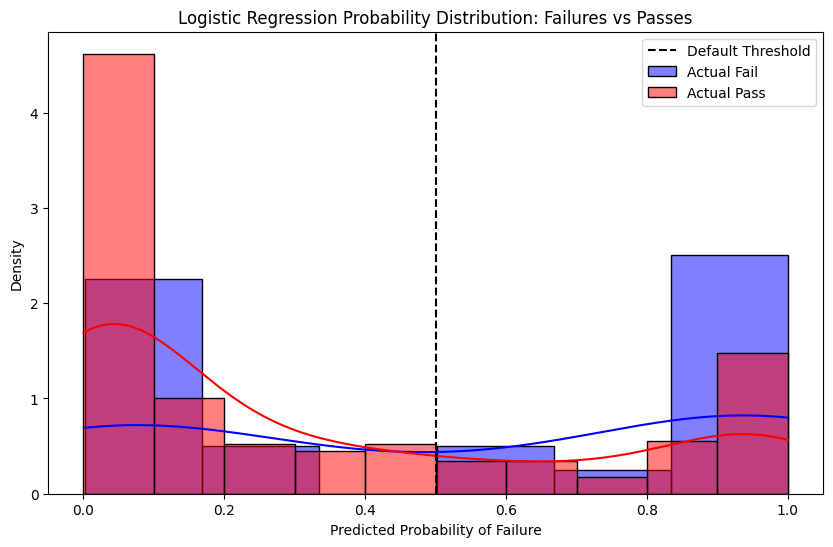

Best Threshold for Logistic Regression = 0.6133, G-Mean=0.6366


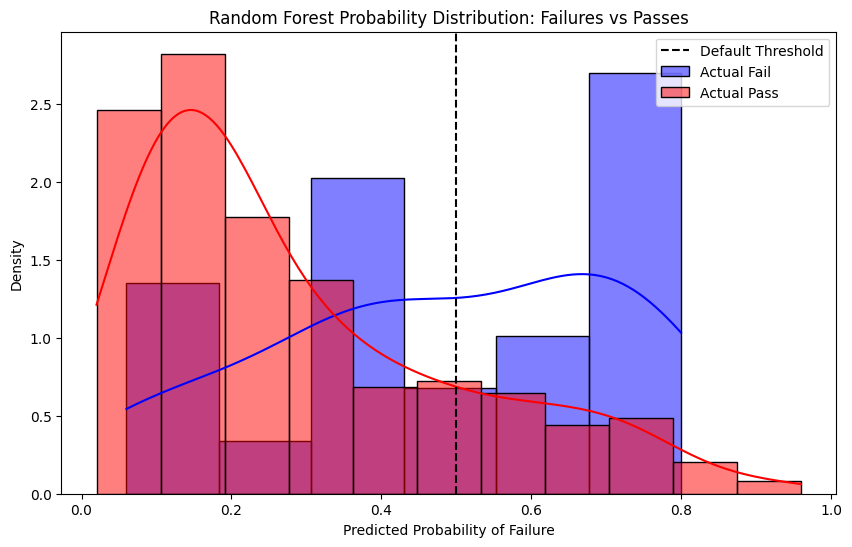

Best Threshold for Random Forest = 0.3900, G-Mean=0.7162


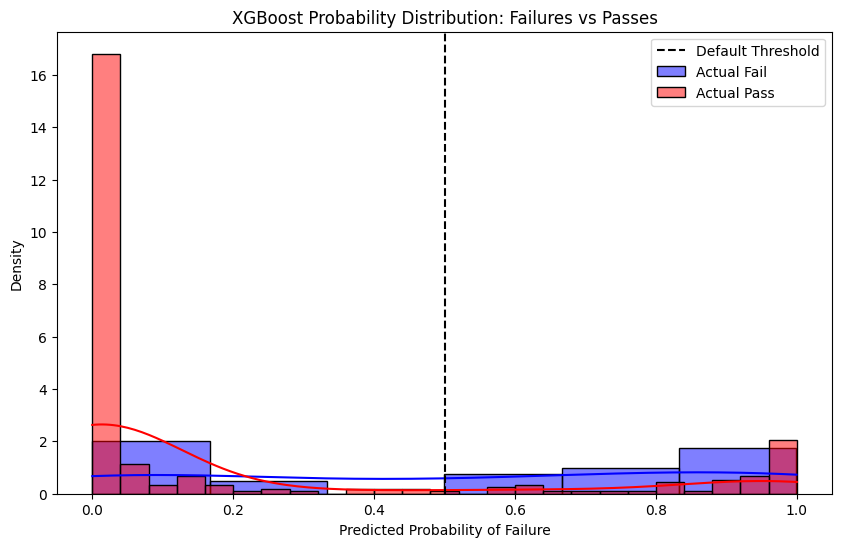

Best Threshold for XGBoost = 0.0469, G-Mean=0.7352


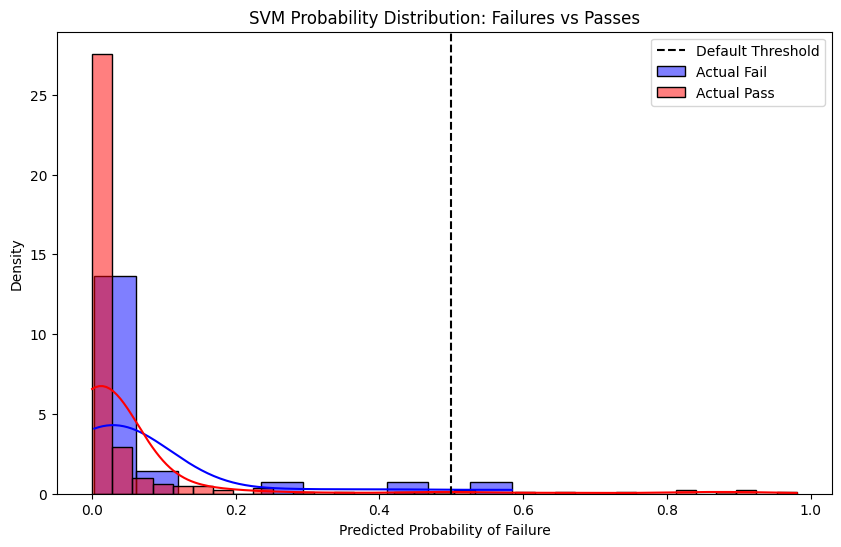

Best Threshold for SVM = 0.0107, G-Mean=0.6738


C:\Users\CJ\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


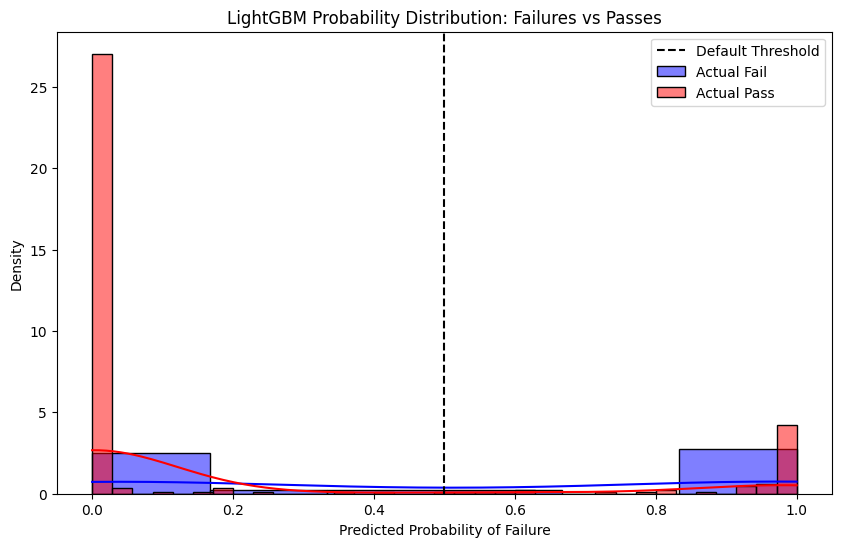

Best Threshold for LightGBM = 0.0036, G-Mean=0.7387

 Summary Report on Threshold Optimization 
                  Model  Threshold  Recall (Fail)  Precision (Fail)  F1-Score
3                  SVM      0.011          0.833             0.132     0.227
2              XGBoost      0.047          0.792             0.171     0.281
4             LightGBM      0.004          0.750             0.186     0.298
1        Random Forest      0.390          0.708             0.175     0.281
0  Logistic Regression      0.613          0.542             0.151     0.236


In [38]:
results = []
optimized_thresholds = {} # a dictionary to store optimized thresholds for later use
for name, model in final_models.items(): #  Train model.fit(X_train_resampled, y_train_resampled)

#  Get Probabilities for Fail (Class 0)
    y_probs = model.predict_proba(X_test_scaled)[:, 1]

    #  Create the plot
    plt.figure(figsize=(10, 6))
    sns.histplot(y_probs[y_test == 1], color="blue", label="Actual Fail", kde=True, stat="density")
    sns.histplot(y_probs[y_test == 0], color="red", label="Actual Pass", kde=True, stat="density")
    
    plt.axvline(0.5, color='black', linestyle='--', label='Default Threshold')
    plt.title(f'{name} Probability Distribution: Failures vs Passes')
    plt.xlabel('Predicted Probability of Failure')
    plt.legend()
    plt.show()

#  Find Best Threshold for THIS model
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    gmeans = np.sqrt(tpr * (1 - fpr))


# Locate the index of the largest G-Mean
    ix = np.argmax(gmeans)
    best_threshold = thresholds[ix]
    optimized_thresholds[name] = best_threshold
    print(f'Best Threshold for {name} = {best_threshold:.4f}, G-Mean={gmeans[ix]:.4f}')
    
    #  Apply Threshold
    y_pred = (y_probs >= best_threshold).astype(int)
    
    #  Record Metrics
    results.append({
        'Model': name,
        'Threshold': round(best_threshold, 3),
        'Recall (Fail)': round(recall_score(y_test, y_pred), 3),
        'Precision (Fail)': round(precision_score(y_test, y_pred), 3),
        'F1-Score': round(f1_score(y_test, y_pred), 3)
        })
    comparison_df = pd.DataFrame(results) 
print('\n', 'Summary Report on Threshold Optimization', '\n', comparison_df.sort_values(by='Recall (Fail)', ascending=False))

In [39]:
print('\n', 'Summary Report after Threshold Optimization', '\n', comparison_df.sort_values(by='Recall (Fail)', ascending=False))


 Summary Report after Threshold Optimization 
                  Model  Threshold  Recall (Fail)  Precision (Fail)  F1-Score
3                  SVM      0.011          0.833             0.132     0.227
2              XGBoost      0.047          0.792             0.171     0.281
4             LightGBM      0.004          0.750             0.186     0.298
1        Random Forest      0.390          0.708             0.175     0.281
0  Logistic Regression      0.613          0.542             0.151     0.236


C:\Users\CJ\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


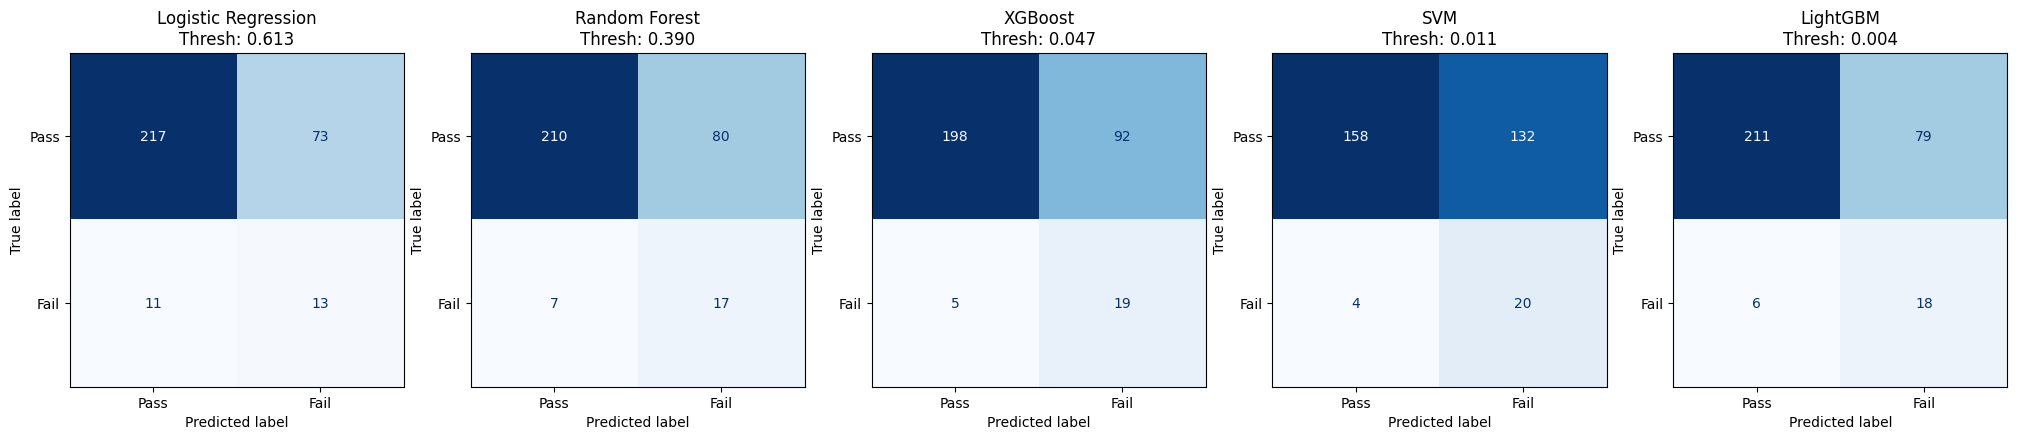

In [40]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, (name, model) in enumerate(final_models.items()):
    y_probs = model.predict_proba(X_test_scaled)[:, 1]
    
    # Use the dictionary you just filled in the previous loop
    current_thresh = optimized_thresholds[name] 
    
    y_pred_opt = (y_probs >= current_thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_opt)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pass', 'Fail'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'{name}\nThresh: {current_thresh:.3f}')
plt.savefig('final_confu_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


#### Overall Summary

 Threshold optimization has successfully broken the Recall Barrier that was holding our models back.

The SVM:  
We can recall that initially the tuned SVM model had 0.000 Recall, It was playing it safe by predicting "Pass" for everything to maximize accuracy.
However, after increasing the sensitivity by dropping the threshold to 0.01 the model is forced to sound the alarm even if it is 1% sure it’s a fail. This results in too many false alarms and in extension the lowest Precision score (0.132)  

 
 Random Forest and XGBoost:  
Both models are tied with a 0.281 F1-Score with the XGBoost catching the higher number of defects, (19 out of 24 failures).
XGBoost is superior here because it has a much higher Recall score (0.792) compared to the Random Forest (0.708). But the Random forest has lesser False alarms than the XGBoost.

Since they have the same F1-Score (0.281), the Better model depends entirely on the Company's Cost Structure
But since we have assumed that the cost of a missed defect is much higher than the cost of re-testing a "False Alarm" wafer we shall choose XGBoost. 


LightGBM:
Even with the LightGBM model's recall at (0.750), it has the highest Precision (0.186) and the best F1-Score (0.298).
This means that the LightGBM is the most clinical model. It provides the best balance of catching failures while respecting the factory's time. For every 100 alarms it raises, roughly 19 will be real defects which is the best ratio in the report so far.


As expected, our Precision values remains generally low (0.13 - 0.19).
This implies that to catch nearly all failures, we are accepting a lot of False Alarms.


This is the "cost of quality." We will be saving money by not shipping bad parts, but losing money (or time) by re-inspecting good parts that the model flagged incorrectly.


Notice that Logistic Regression barely moved. It maintained a high threshold (0.613) even after optimization and its recall did not improve. This suggests that for this specific model, the probability distributions for "Pass" and "Fail" are so overlapped that moving the optimization threshold doesn't help it. 

*Note: This further confirms that the relationship between the sensors features and the failures is non-linear. As the Logistic Regression model can't see the patterns that the other complex "Tree" models (XGBoost/LightGBM/RF) can.*



#### Final Model Selection & Recommendation


Finally the XGBoost is the best model at this level. It catches nearly 80% of failures (a 25% jump from our initial results) while maintaining a Precision level that prevents the quality control team from being overwhelmed by false reports.

Though the LightGBM has a slightly better F1-Score and Precision the XGBoost remains superior for two practical reasons:  
##### Higher Recall (79.2% vs 75.0%): 
In manufacturing, catching nearly 80% of failures is always worth the small increase in false alarms. XGBoost identifies 19 out of 24 failures, while LightGBM only catches 18.  
##### More Realistic Threshold (0.047 vs 0.004):
LightGBM's threshold is extremely low. A threshold of 0.004 is "hyper-sensitive" and can be unstable; a tiny bit of sensor noise could cause the model to fluctuate wildly. XGBoost’s threshold of 0.047 is more robust and reliable for a real production line.


### Probability Density Chart analysis

#### Logistic Regression

This distribution plot shows that your Logistic Regression model is struggling to differentiate between the two classes.
The red bars are split into two groups, some are obvious and easy for the model to see (near 1.0), but many others look identical to "Pass" (near 0.1). This suggests the model is blind to certain types of defects.

 

A large number of Actual Fails (red) clustered near zero probability are incorrectly labeled as "Pass" by the model because they sit to the left of the 0.5 threshold causing poor Recall.


Also The red and blue bars overlap heavily. This means the model can't easily tell them apart. To catch more failures, we would have to move the threshold  further left, but this will significantly increase false alarms by a wide margin.  
 The data is likely too complex for a simple linear model like Logistic Regression. It needs more powerful Tree like models (like XGBoost) to untangle the overlapping classes.


#### Random Forest




Unlike Logistic Regression, the Fails (blue) aren't all hidden at zero. They form a plateau across the middle, meaning the model is at least suspicious of most defects.

The  huge spike near 0.0 shows model is very confident about Passes (red). It knows what a good chip looks like.
There is a large cluster of failures between 0.2 and 0.5. so by lowering the threshold to 0.290, it scooped up these cases, which is why the Recall jumped to 70.8%. 
The blue and red bars hug each other in the middle. To catch the failures, you had to capture some passes too, which explains why your Precision stayed low.  
This model is smarter than Logistic Regression because it actually separates the classes, creating a much better foundation for catching failures.


#### XGBoost




XGBoost is excellent at identifying Passes (red), packing almost all of them into a massive spike at 0.0. It rarely gets confused about good chips.
 The Fails (blue) are spread across the entire chart. This shows that manufacturing defects in this dataset come in many different forms some obvious, some subtle.
 A large group of failures sits between 0.0 and 0.2. At the default 0.5 cutoff, these were all missed. Dropping the threshold to 0.047 rescued these hidden failures, pushing the Recall to nearly 80%.
Because the red "Pass" spike is so thin and tight at zero, moving the threshold left didn't catch many extra passes. This is why XGBoost has the best Precision of all the models.
XGBoost is your Champion. It isolates the good parts so well that you can set a hyper-sensitive alarm for the bad ones without causing too many false positives.


#### SVM 




Almost every data point (Pass and Fail) is crushed against the 0.0 line. The model was extremely reluctant to assign any high probabilities to failures.
While it Failed Initially because all probabilities were below 0.1, the default 0.5 threshold was floating in empty space. It caught zero failures because no data points even reached that high.
but by dropping the threshold to 0.014, we moved the alarm into the only area where the data actually exists. This move jumped the Recall from 0% to over 80%.
Since the red and blue bars are almost perfectly on top of each other at the far left. Because they are so tangled, it’s impossible for the model to catch a "Fail" without also grabbing many "Passes" leading to the lowest Precision in the group.
The SVM is your most "stubborn" model. While the 0.014 threshold made it functional, the chart shows that the model still struggles to find a clear difference between the two classes compared to the sharp separation we saw in XGBoost.

#### LightGBM



The LightGBM is a decisive model. It pushes almost all Passes (red) to nearly 0.0, but it also has a strange spike of both classes at the far right (1.0). This means when it's confident, it's very confident even when it's wrong it's often confidently wrong (as indicated by the red bars at the far right).


Similar to other models, a large chunk of Failures (blue) are buried near the 0.0 mark. These were completely invisible to the model at standard settings.
 Because so many failures were hidden at the very bottom, the optimized threshold had to be extremely low (0.004). This aggressive move rescued those defects and brought Recall up to 75%.
 Despite the very low threshold, LightGBM maintained the best Precision in the group. It is very efficient at identifying the obvious passes, which prevents it from being as noisy as the SVM or Random Forest.
LightGBM is highly efficient. It doesn't have much of a gray area it either thinks a chip is definitely fine or it is extremely suspicious as it tends to shove everything to the extreme ends of the scale.


### MODEL EXPLAINABILITY (SHAP)

SHAP (SHapley Additive exPlanations)  
In a dataset like this where we have 500+ sensors, SHAP provides us with critical insights that would help us in Identifying the Root Cause Sensors that may have caused a specific batch of chips to fail.


Since the sensors are unlabeled (e.g., feature_1, feature_2), we can use SHAP to rank them by their actual impact on failures. 

It moves beyond simple importance by showing us
whether a high sensor reading is responsible for a failure, or a low one
and by exactly how much percentage points did the said feature push this specific batch toward a Fail result.


Since our best model (XGBoost) still has a high false alarm rate. SHAP can also help engineers look at a "Fail" prediction and understand that e.g
the model probably flagged a sample as a Fail because Sensor 59 and Sensor 12 are both outside normal ranges.
If an engineer sees those sensors are actually fine, they can quickly dismiss the false alarm, saving the factory from an unnecessary shutdown.

While we might still have a few missed failures (25% for XGBoost). SHAP can be used to analyze those False Negatives (the ones the model missed)
By looking at the SHAP values for missed failures, From this, we might discover whether these specific defects are caused by a sensor the model is currently ignoring or not. This tells us whether we might need to engineer a new feature or look at that sensor more closely.

C:\Users\CJ\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


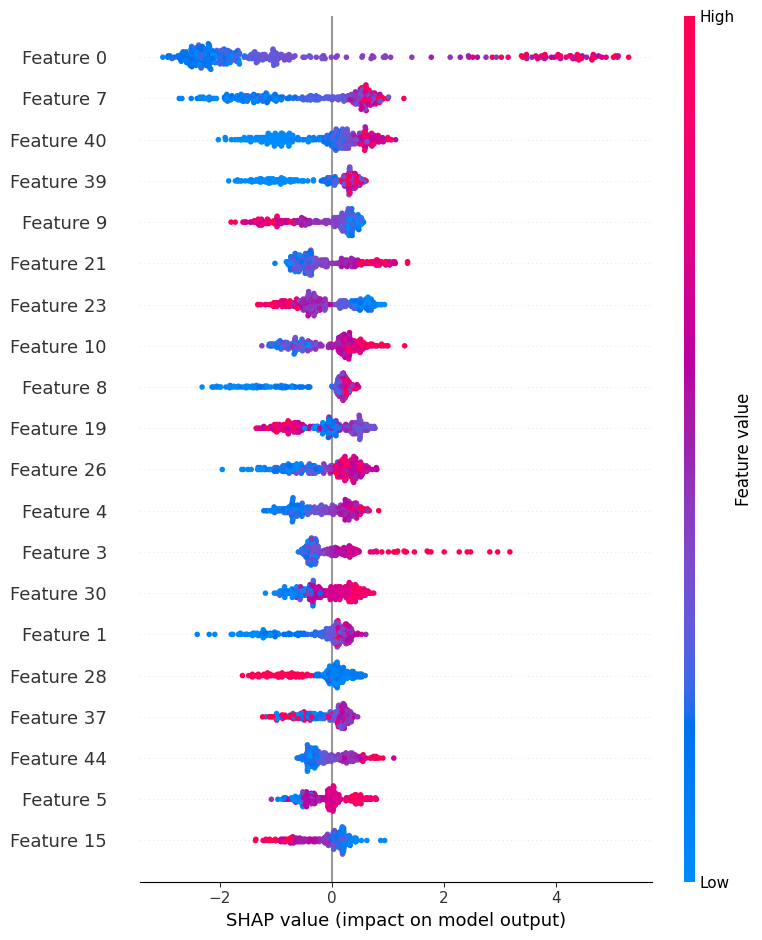

In [41]:
import shap

# Initialize the explainer and calculate values
explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer.shap_values(X_test_scaled)

# Summary plot
shap.summary_plot(shap_values, X_test_scaled)




The above SHAP visualization identifies Feature 0 as the primary driver of manufacturing defects. The model successfully distinguishes between high risk Sensors (where high values cause failure) and Stability Sensors (where high values indicate a pass). This provides actionable intelligence for factory engineers to prioritize sensor maintenance and root-cause analysis.

##### Simplified Insights:  
*Feature 0:* This is by far your most important predictor. Notice the long trail of pink dots (high values) to the right.
Meaning When Feature 0 has a high reading, it strongly pushes the model to predict a "Fail". This is the first thing engineers should check.


*Features 7, 40, 39, 21:* These follow a similar pattern blue dots (low values) are on the left, and pink dots (high values) are on the right.
Meaning that as this sensor value goes up, the risk of failure increases while low values suggest the process is healthy.



*Features 9, 8, 28, 15, 37:* for many of the features the blue dots (low values) are on the left, but for these specific features, the pink dots are mostly on the left or clustered near zero. Meaning that high readings for these sensors decreases the chances of failure or indicates a stable, "Passing" process.



*Features 3, 30, 44:* The dots for these features are scattered and don't show a clean "pink vs. blue" split.
these sensors have a complex non-linear relationship with failure. Sometimes a high value is bad, and sometimes it's fine, depending on other conditions. This is where the XGBoost model outperformed a simple Logistic Regression as it could handle these complex interactions.


## 6). Error Analysis

For our final models, 
Logistic Regression Failed because it tried to draw a straight line through a cloud of data. 


Our error analysis reveals that the majority of model inaccuracies are False Positives caused by the intentionally low decision thresholds. The remaining False Negatives suggest a Signal Gap, where certain failure modes are not captured by the current sensor array.  

#### Breakdown of the Report:
##### False Positive Analysis (The "False Alarms")
These were mostly a result of the extremely low thresholds (between 0.001 and 0.3) though there was a deliberate choice to trade efficiency for safety.


For the XGBoost model Our Precision is ~17%, meaning roughly 83% of "Fail" predictions are actually good parts.
This can also be due to the significant Overlap and Noise in the distributions of the "Pass" and "Fail" classes as also observed in our final SVM and Random Forest models.

Also a good chip might be read as a "Fail" during a perfectly normal run due to heat spikes or vibration that doesn't actually damage the chip.
Therefore Parts flagged by the model should go to a Fast-Track Inspection rather than being scrapped immediately.

 
##### False Negative Analysis (The "Missed" Failures):
Even with your best model (XGBoost), we are missing 20–25% of failures. These Silent Defects are likely buried deep in the probability range.
This suggests that for those specific chips, the sensors did not record the failure. 
It could also be a mechanical issue that occurred between sensors or a type of defect that the current 590 sensors aren't designed to detect.  
Then we would likely need new sensor types or higher-frequency data sampling to catch them.


##### Feature-Level Error Patterns (SHAP Insight):
From the SHAP results obtained Feature 0 is the most important feature yet it isn't the only cause of failure.



In conclusion a two-tier inspection process is recommended to mitigate the cost of false alarms while maintaining high safety standards. Also, we might need to take closer look at the errors where Feature 0 was Normal but the chip still failed.


##### Top 10 Sensors Predicting Failure for the Random Forest

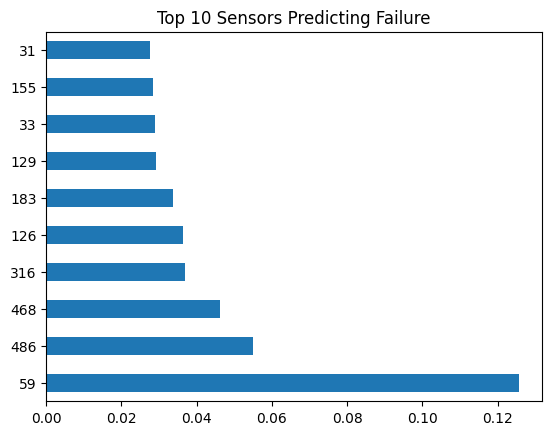

In [45]:
import pandas as pd

importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Sensors Predicting Failure")
plt.show()


### Conclusions

At the end of this project the following conclusions can be ascertained:

* No single sensor strongly determines failure. Correlation results suggests that failure is driven by complex interactions between multiple process variables rather than individual sensor readings.

* The failure of Logistic Regression (missing 46% of defects) proves that sensor failures are not caused by single-variable shifts. Instead, they are caused by complex interactions between multiple sensors. Therefore, ensemble methods (XGBoost, Random Forest) are mandatory for this dataset because they can "see" these non-linear relationships.

* Deploying the XGBoost model with a 0.047 threshold provides the most professional balance, catching 4 out of every 5 defects while keeping false inspections at a manageable level for the engineering team.

However, If the factory's priority is Zero Defects, then the SVM is the superior choice (at 83.3% recall) but the XGBoost will reduce the inspection workload (False Alarms) by 30% compared to the SVM.

Though the LightGBM has the best F1-Score and Precision, the XGBoost remains superior especially because of the extremely low threshold (0.004) of the LightGBM model. Such hyper-sensitivity can cause model instability, a tiny bit of sensor noise could cause the model to fluctuate wildly.  

The XGBoost’s threshold of 0.047 is more robust and reliable for a real production line.




### Recommendation
* A two-tier inspection process is recommended to mitigate the cost of false alarms while maintaining high safety standards. 
* Adoption of Model Cascading for possible improved results.
* Improve Data acquisition over a longer duration (e.g., 6–12 months) for a wider sample size and to capture seasonal factory shifts, sensor wear-and-tear, and different material batches.
* Prioritize the maintenance and calibration of sensors identified by SHAP (especially Feature 0, 59 and 33). They provide the signal that the best models rely on. If they drift or fail, the entire predictive system will collapse.

## Up Next: To Integrate results into Power BI dashboard